# Hallmarks trait coverage

**Environment:** `clamp-analyses`

Trait coverage across ARCHS4 Hall coverage models using PhenomeXcan GLS summaries. Coverage is the proportion of all 4,049 PhenomeXcan traits significantly associated with at least one LV at FDR < 0.05.

In [1]:
library(here)
library(ggplot2)
library(dplyr)
library(readr)
library(grid)

FindExistingPath <- function(paths) {
  existing <- paths[file.exists(paths)]
  if (length(existing) == 0) {
    stop("None of these paths exist: ", paste(paths, collapse = ", "))
  }
  existing[[1]]
}

base_output_dir <- here("output/01_model_building/04_archs4/06_bp_coverage_rshall")
meta_path <- FindExistingPath(c(
  here("output/01_model_building/04_archs4/01_archs4_preprocess/metadata_filtered.rds"),
  here("output/01_model_building/04_archs4/metadata_filtered.rds")
))

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title = element_text(size = 24, colour = "black"),
      axis.title.y = element_text(margin = margin(r = 18)),
      axis.text = element_text(size = 18, colour = "black"),
      axis.line = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor = element_blank(),
      legend.position = "none",
      plot.title = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(face = "bold", size = 18),
      plot.margin = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Summarize trait coverage

In [2]:
GetModelSpec <- function(path) {
  model_dir <- basename(dirname(path))
  pieces <- regmatches(model_dir, regexec("^hall_coverage_rs([0-9]+)_seed_([0-9]+)$", model_dir))[[1]]
  if (length(pieces) != 3) {
    stop("Could not parse model directory: ", model_dir)
  }

  list(
    model        = model_dir,
    coverage_pct = as.integer(pieces[2]),
    seed         = as.integer(pieces[3])
  )
}

GetSampleCount <- function(path, coverage_pct, total_samples) {
  sample_info_path <- file.path(dirname(path), "subsample_info.rds")
  if (file.exists(sample_info_path)) {
    sample_info <- readRDS(sample_info_path)
    if (!is.null(sample_info$n_samples)) {
      return(as.integer(sample_info$n_samples))
    }
  }

  as.integer(round(total_samples * coverage_pct / 100))
}

SummarizeTraitCoverage <- function(path, total_samples, total_traits, fdr.cutoff = 0.05) {
  spec <- GetModelSpec(path)
  summary_df <- readr::read_tsv(path, show_col_types = FALSE, progress = FALSE)

  expected_cols <- c("phenotype", "phenotype_desc", "lv", "pvalue", "fdr")
  if (!all(expected_cols %in% colnames(summary_df))) {
    stop("Unexpected columns in ", path, ": ", paste(colnames(summary_df), collapse = ", "))
  }

  # TMP: remove degenerate LVs (zero p-values + anomalously broad associations)
  # See tmp_degenerate_lv.ipynb for full investigation
  if (spec$coverage_pct == 10) summary_df <- dplyr::filter(summary_df, lv != "LV834")
  if (spec$coverage_pct == 10 && spec$seed == 2L) summary_df <- dplyr::filter(summary_df, lv != "LV509")
  if (spec$coverage_pct == 10 && spec$seed == 3L) summary_df <- dplyr::filter(summary_df, lv != "LV593")
  if (spec$coverage_pct == 50 && spec$seed %in% c(1L, 2L)) summary_df <- dplyr::filter(summary_df, lv != "LV519")
  if (spec$coverage_pct == 50 && spec$seed == 2L) summary_df <- dplyr::filter(summary_df, lv != "LV836")
  summary_df <- dplyr::mutate(summary_df, fdr = p.adjust(pvalue, method = "BH"))

  sig_df <- summary_df %>%
    dplyr::filter(fdr < fdr.cutoff)

  n_phenotypes <- total_traits
  n_lvs        <- dplyr::n_distinct(summary_df$lv)
  n_sig_traits <- dplyr::n_distinct(sig_df$phenotype)
  n_sig_lvs    <- dplyr::n_distinct(sig_df$lv)

  data.frame(
    model        = spec$model,
    coverage_pct = spec$coverage_pct,
    seed         = spec$seed,
    n_samples    = GetSampleCount(path, spec$coverage_pct, total_samples),
    n_rows       = nrow(summary_df),
    n_sig_rows   = nrow(sig_df),
    n_phenotypes = n_phenotypes,
    n_lvs        = n_lvs,
    n_sig_traits = n_sig_traits,
    n_sig_lvs    = n_sig_lvs,
    prop_trait   = n_sig_traits / total_traits,
    prop_lv      = n_sig_lvs / n_lvs,
    path         = path,
    stringsAsFactors = FALSE
  )
}

PHENOMEXCAN_TOTAL_TRAITS <- 4049

meta <- readRDS(meta_path)
total_samples <- meta$n_samples

summary_paths <- list.files(
  base_output_dir,
  pattern = "gls-summary-phenomexcan\\.tsv\\.gz$",
  recursive = TRUE,
  full.names = TRUE
)

summary_paths <- summary_paths[grepl("/hall_coverage_rs[0-9]+_seed_[0-9]+/gls-summary-phenomexcan\\.tsv\\.gz$", summary_paths)]
summary_paths <- summary_paths[!grepl("/hall_coverage_rs100_seed_[0-9]+/", summary_paths)]
summary_paths <- sort(summary_paths)

stopifnot(length(summary_paths) == 18)

results <- lapply(summary_paths, SummarizeTraitCoverage,
                  total_samples = total_samples,
                  total_traits = PHENOMEXCAN_TOTAL_TRAITS,
                  fdr.cutoff = 0.05)
results_df <- do.call(rbind, results) %>%
  dplyr::arrange(coverage_pct, seed)
rownames(results_df) <- NULL

expected_coverage <- as.integer(c(1, 5, 10, 25, 50, 75))
coverage_counts <- table(results_df$coverage_pct)
stopifnot(identical(sort(unique(results_df$coverage_pct)), expected_coverage))
stopifnot(all(coverage_counts[as.character(expected_coverage)] == 3))
stopifnot(all(results_df$n_sig_traits <= results_df$n_phenotypes))
stopifnot(all(results_df$n_sig_lvs <= results_df$n_lvs))
stopifnot(all(results_df$prop_trait >= 0 & results_df$prop_trait <= 1))
stopifnot(all(results_df$prop_lv >= 0 & results_df$prop_lv <= 1))

print(results_df)

                       model coverage_pct seed n_samples  n_rows n_sig_rows
1   hall_coverage_rs1_seed_1            1    1      6056  518272       1083
2   hall_coverage_rs1_seed_2            1    2      6056  518272        973
3   hall_coverage_rs1_seed_3            1    3      6056  526370       1413
4   hall_coverage_rs5_seed_1            5    1     30281 2850496       3790
5   hall_coverage_rs5_seed_2            5    2     30281 2826202       3862
6   hall_coverage_rs5_seed_3            5    3     30281 2874790       3681
7  hall_coverage_rs10_seed_1           10    1     60561 3842501       5400
8  hall_coverage_rs10_seed_2           10    2     60561 3846550       5229
9  hall_coverage_rs10_seed_3           10    3     60561 3846550       5032
10 hall_coverage_rs25_seed_1           25    1    151404 5377072       6099
11 hall_coverage_rs25_seed_2           25    2    151404 5360876       6272
12 hall_coverage_rs25_seed_3           25    3    151404 5360876       6374
13 hall_cove

## Plot coverage

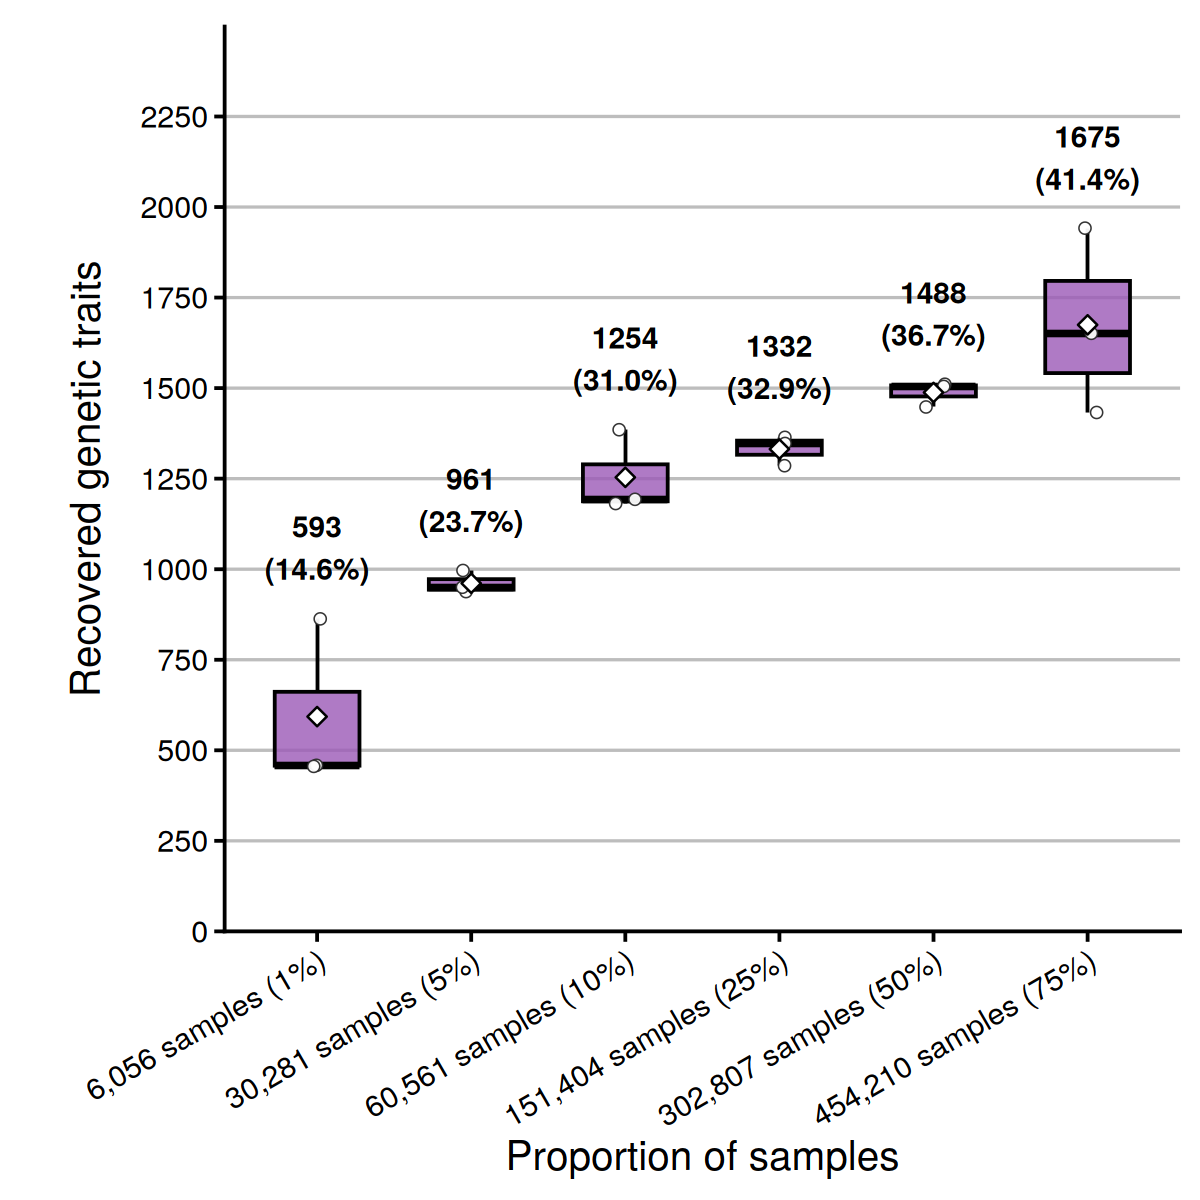

In [3]:
options(repr.plot.width = 10, repr.plot.height = 10)

sample_counts <- results_df %>%
  dplyr::group_by(coverage_pct) %>%
  dplyr::summarise(med_n = round(median(n_samples)), .groups = "drop") %>%
  dplyr::arrange(coverage_pct)

label_map <- setNames(
  paste0(format(sample_counts$med_n, big.mark = ","), " samples (", sample_counts$coverage_pct, "%)"),
  sample_counts$coverage_pct
)

results_df <- results_df %>%
  dplyr::mutate(
    coverage_label = factor(label_map[as.character(coverage_pct)], levels = label_map)
  )

purple_fill <- "#9b59b6"
trait_label_offset <- max(results_df$n_sig_traits, na.rm = TRUE) * 0.055

trait_label_df <- results_df %>%
  dplyr::group_by(coverage_label) %>%
  dplyr::summarise(
    mean_nsig = mean(n_sig_traits, na.rm = TRUE),
    mean_prop = mean(prop_trait * 100, na.rm = TRUE),
    max_y     = max(n_sig_traits, na.rm = TRUE),
    label_y   = max_y + trait_label_offset,
    label     = paste0(sprintf("%.0f", mean_nsig), "\n(", sprintf("%.1f", mean_prop), "%)"),
    .groups   = "drop"
  )

p_trait <- ggplot(results_df, aes(x = coverage_label, y = n_sig_traits)) +
  geom_boxplot(width = 0.55, fill = scales::alpha(purple_fill, 0.80), colour = "black",
               linewidth = 0.8, outlier.shape = NA) +
  geom_jitter(width = 0.08, size = 2.8, shape = 21, fill = "white",
              colour = "#2b2b2b", stroke = 0.5, alpha = 0.95) +
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3.8,
               fill = "white", colour = "black", stroke = 0.8) +
  geom_text(data = trait_label_df, aes(x = coverage_label, y = label_y, label = label),
            inherit.aes = FALSE, size = 6.2, fontface = "bold", vjust = 0) +
  scale_y_continuous(limits = c(0, NA), breaks = seq(0, 3000, by = 250),
                     expand = expansion(mult = c(0, 0.22))) +
  labs(x = "Proportion of samples", y = "Recovered genetic traits") +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1))

p_trait

## Export panel data

In [4]:
PANEL_DIR_FIG4 <- here("output/99_panels/fig4")
dir.create(PANEL_DIR_FIG4, recursive = TRUE, showWarnings = FALSE)

export_df <- results_df %>%
  dplyr::select(model, coverage_pct, seed, n_samples, n_rows, n_sig_rows,
                n_phenotypes, n_lvs, n_sig_traits, n_sig_lvs,
                prop_trait, prop_lv, path)

write.csv(export_df, file.path(PANEL_DIR_FIG4, "hall_trait_coverage.csv"), row.names = FALSE)
message("Saved hall_trait_coverage.csv to ", PANEL_DIR_FIG4)

Saved hall_trait_coverage.csv to /home/msubirana/Documents/pivlab/clamp-analyses/output/99_panels/fig4

